In [1]:
import pandas as pd

In [2]:
import os
os.listdir("../dataset")

['.gitkeep', 'dna_sequences.csv', 'noncoding.fasta']

In [3]:
data = pd.read_csv("../dataset/dna_sequences.csv")
data.head()

,sequence,label
0,TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...,Promoter
1,TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...,Promoter
2,GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...,Promoter
3,AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...,Promoter
4,TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...,Promoter


In [14]:
data = data.dropna(subset=['label'])
data = data[data['label'].str.strip() != '']

data['label'].unique()
print(data['label'].value_counts())

label
Noncoding    201
Promoter     103
Coding        71
Name: count, dtype: int64


In [5]:
from sklearn.feature_extraction.text import CountVectorizer


In [6]:
k = 4 
vectorizer = CountVectorizer(analyzer='char', ngram_range=(k, k))

In [7]:
X = vectorizer.fit_transform(data['sequence'])
y = data['label']

In [8]:
print(X.shape)
print(vectorizer.get_feature_names_out()[:10])

(375, 256)
['aaaa' 'aaac' 'aaag' 'aaat' 'aaca' 'aacc' 'aacg' 'aact' 'aaga' 'aagc']


In [9]:
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 300
Testing samples: 75


In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Try different alpha values
for a in [1.0, 0.5, 0.1, 0.01]:
    
    model = MultinomialNB(alpha=a)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print("Alpha:", a, "Accuracy:", acc)


Alpha: 1.0 Accuracy: 0.6533333333333333
Alpha: 0.5 Accuracy: 0.6533333333333333
Alpha: 0.1 Accuracy: 0.6533333333333333
Alpha: 0.01 Accuracy: 0.6533333333333333


In [11]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.6533333333333333

Classification Report:

              precision    recall  f1-score   support

      Coding       0.52      0.79      0.63        14
   Noncoding       0.75      0.60      0.67        40
    Promoter       0.64      0.67      0.65        21

    accuracy                           0.65        75
   macro avg       0.64      0.68      0.65        75
weighted avg       0.68      0.65      0.66        75



In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

import joblib

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# 👇 ADD THESE TWO LINES RIGHT HERE
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7866666666666666

Classification Report:

              precision    recall  f1-score   support

      Coding       0.82      0.64      0.72        14
   Noncoding       0.79      0.85      0.82        40
    Promoter       0.76      0.76      0.76        21

    accuracy                           0.79        75
   macro avg       0.79      0.75      0.77        75
weighted avg       0.79      0.79      0.78        75

Random Forest Accuracy: 0.7866666666666666
              precision    recall  f1-score   support

      Coding       0.82      0.64      0.72        14
   Noncoding       0.79      0.85      0.82        40
    Promoter       0.76      0.76      0.76        21

    accuracy                           0.79        75
   macro avg       0.79      0.75      0.77        75
weighted avg       0.79      0.79      0.78        75



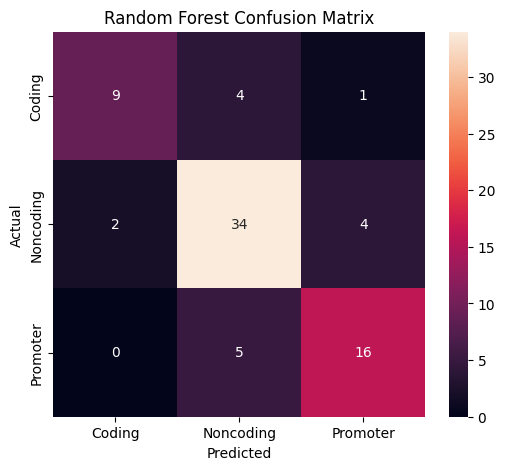

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, rf_pred)

labels = np.unique(y)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()